In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import Aer
from qiskit import *
from qiskit.visualization import plot_bloch_multivector
%matplotlib inline

In [ ]:
from qiskit_aer import AerSimulator # Update via Qiskit v1.0+

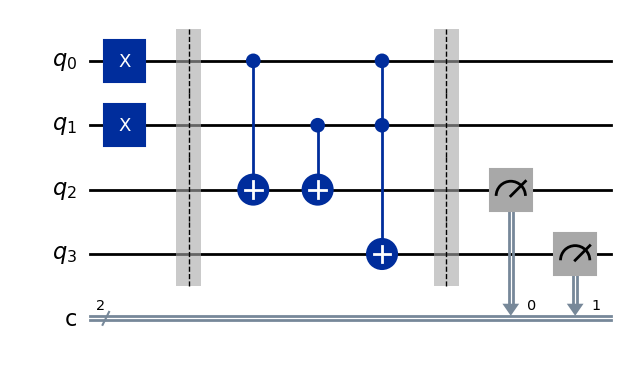

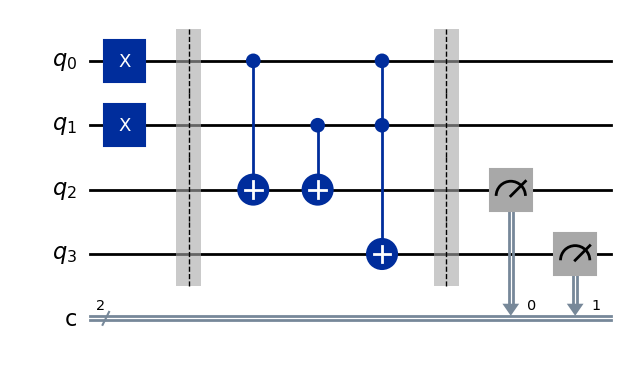

In [4]:
circuit = QuantumCircuit(4, 2)
circuit.x(0)
circuit.x(1)
circuit.barrier()

circuit.cx(0, 2)
circuit.cx(1, 2)
circuit.ccx(0, 1, 3)

circuit.barrier()
circuit.measure(2, 0)
circuit.measure(3, 1)
circuit.draw(output='mpl')

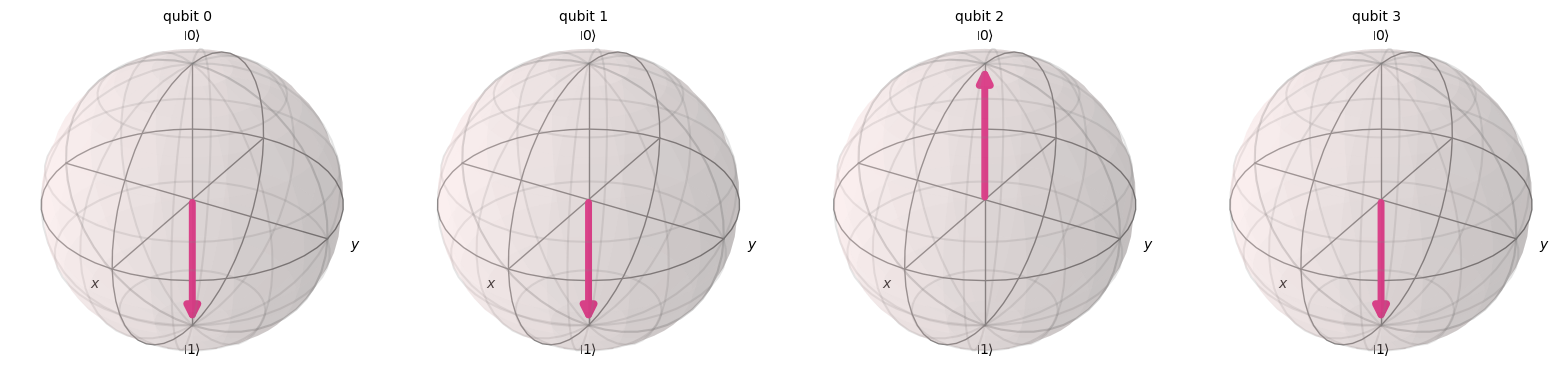

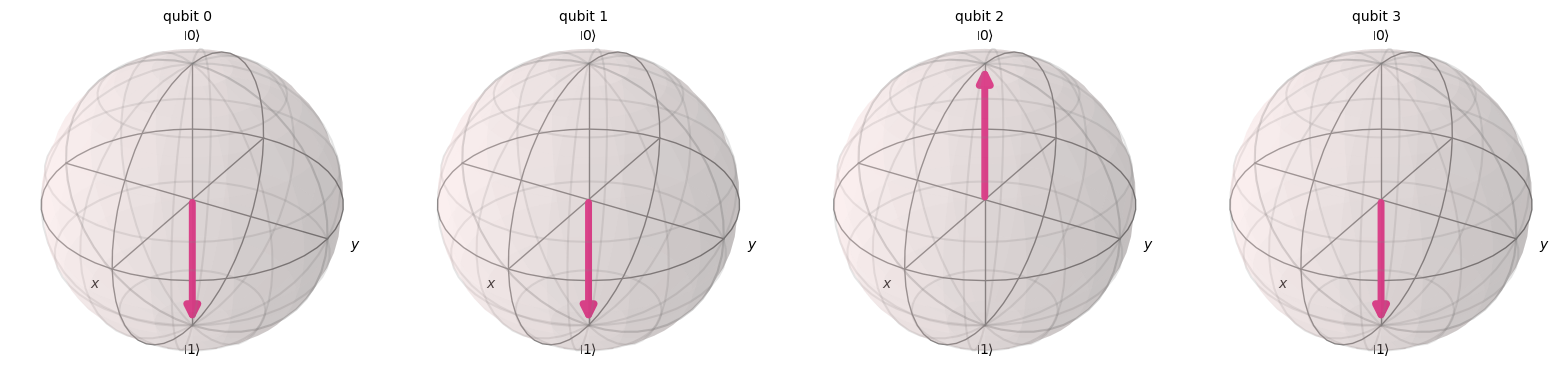

In [5]:
simulator = Aer.get_backend('statevector_simulator')
compiled_circuit = transpile(circuit, backend=simulator)
result = simulator.run(compiled_circuit).result()
plot_bloch_multivector(result.get_statevector())

In [6]:
# UPDATE: Code updated after recording to resolve breaking changes from Qiskit 1.0
from qiskit.providers.basic_provider import BasicProvider
simulator = BasicProvider().get_backend('basic_simulator')
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1).result()
counts = result.get_counts()
print(f'SUM is {list(counts.keys())[0][1]}')
print(f'CARRY-OUT is {list(counts.keys())[0][0]}')

SUM is 0
CARRY-OUT is 1


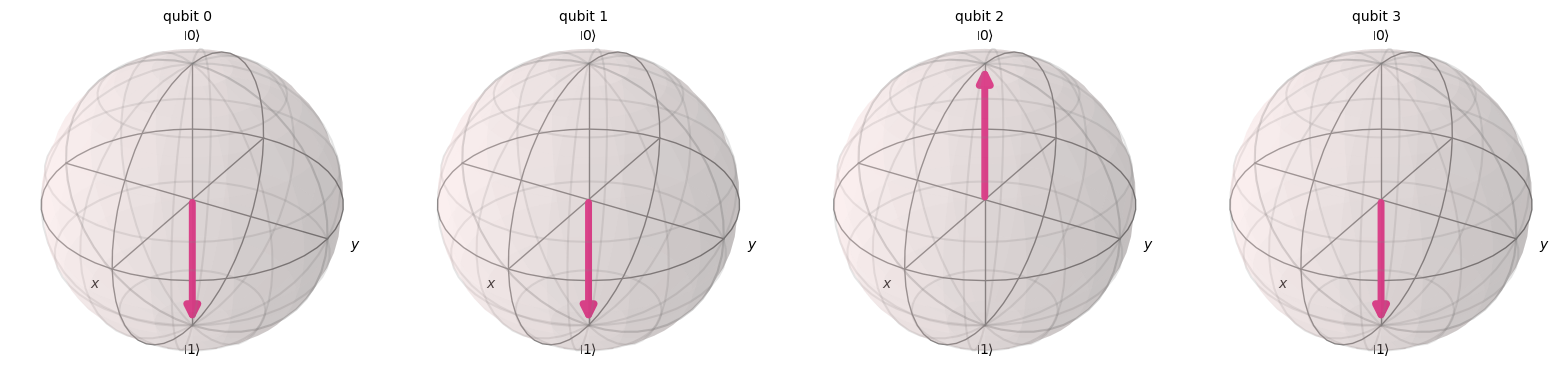

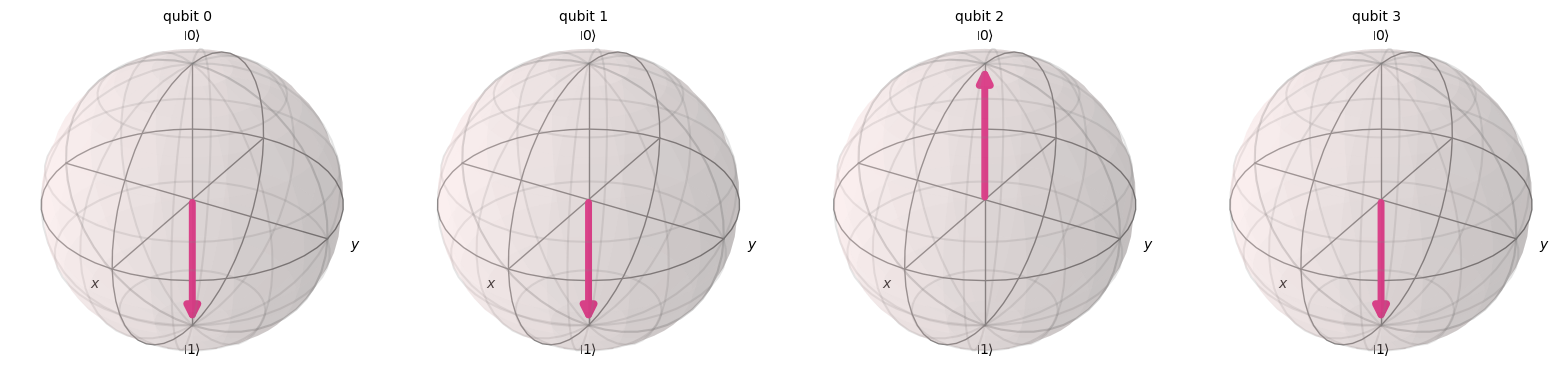

In [7]:
# 2. Instruct the circuit to save the statevector at this point
circuit.save_statevector()

# 3. Setup the AerSimulator to use the statevector method
simulator = AerSimulator(method='statevector')

result = simulator.run(circuits=circuit).result()
state_vector = result.get_statevector()
plot_bloch_multivector(state_vector)